In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel("../../DATA/Telco_customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


 Are there any missing values?

In [4]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

Should we remove or keep the missing values?

In [5]:
df = df.drop(columns=["Churn Reason"])

 Are all columns stored with the correct data type?

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

 Can we convert Total Charges into numeric values?

In [7]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

 Did converting the column create missing values?

In [9]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [10]:
df = df.dropna()

 Are there duplicated rows?

In [11]:
df.duplicated().sum()

np.int64(0)

Are all columns useful for machine learning?

In [12]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV'],
      dtype='object')

 Are all columns useful for machine learning?

In [13]:
df = df.drop(columns=[
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Lat Long",
    "Churn Value",
    "Churn Score",
    "Zip Code",
    "Latitude",
    "Longitude"
])

Are there outliers in numerical features?

In [14]:
import matplotlib.pyplot as plt

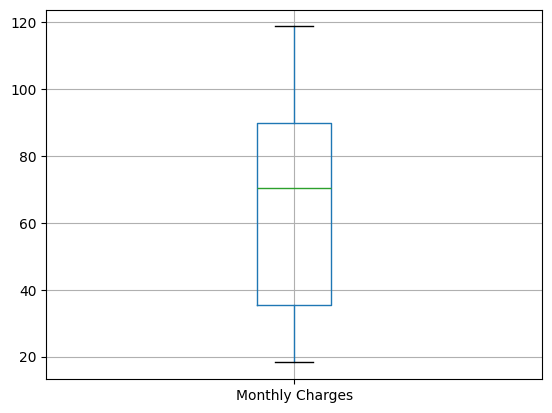

In [15]:
df.boxplot(column="Monthly Charges")

plt.show()

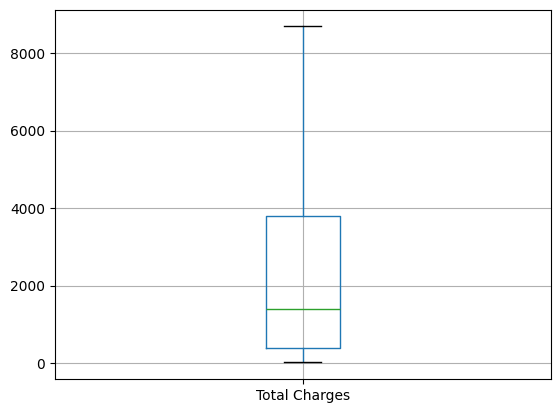

In [16]:
df.boxplot(column="Total Charges")

plt.show()

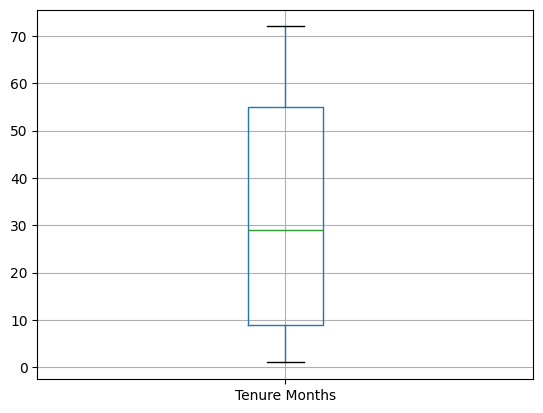

In [17]:
df.boxplot(column="Tenure Months")

plt.show()

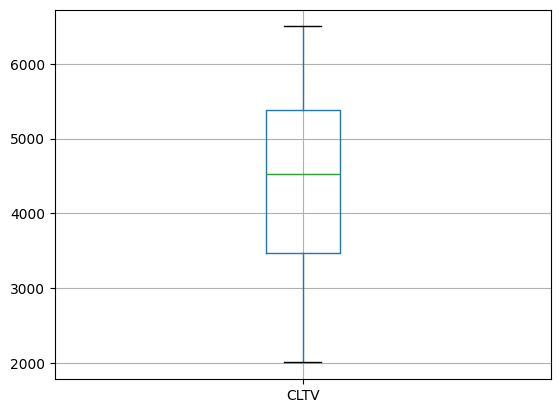

In [18]:
df.boxplot(column="CLTV")

plt.show()

 Which columns are categorical?

In [19]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label'],
      dtype='object')

Can machine learning models understand text?

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le = LabelEncoder()

In [22]:
df["Gender"] = le.fit_transform(df["Gender"])

Can we encode all binary categorical features?

In [23]:
binary_columns = [
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Paperless Billing",
    "Churn Label"
]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

 How do we encode columns with more than two categories?

In [24]:
df = pd.get_dummies(
    df,
    columns=[
        "Contract",
        "Payment Method",
        "Internet Service"
    ]
)

 Should numerical features be scaled?

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

numerical_columns = numerical_columns.drop("Churn Label")


In [27]:
scaler = StandardScaler()

In [28]:
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

 Can we create a new feature that may help prediction? 
 أنشأنا Feature جديدة تمثل متوسط تكلفة العميل.

In [29]:
df["Average Charges"] = (
    df["Total Charges"] /
    (df["Tenure Months"] + 1)
)

 Can we save the cleaned dataset?

In [30]:
df.to_csv("../../DATA/processed_telco.csv", index=False)

In [31]:
df.select_dtypes(include="object").columns

Index([], dtype='object')